In [34]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("grassknoted/asl-alphabet")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'asl-alphabet' dataset.
Path to dataset files: /kaggle/input/asl-alphabet


In [35]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [36]:
DATA_DIR = "/kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train"
IMG_SIZE = 64


In [37]:
def load_data(data_dir, img_size=64, max_per_class=1000):  # Limit for faster hackathon prototyping
    X, y = [], []
    labels = sorted(os.listdir(data_dir))

    for idx, label in enumerate(labels):
        path = os.path.join(data_dir, label)
        count = 0
        for img_name in os.listdir(path):
            if count >= max_per_class:
                break
            img_path = os.path.join(path, img_name)
            img = cv2.imread(img_path)
            img = cv2.resize(img, (img_size, img_size))
            X.append(img)
            y.append(idx)
            count += 1

    X = np.array(X, dtype='float32') / 255.0
    y = to_categorical(np.array(y))
    return X, y, labels

X, y, label_list = load_data(DATA_DIR, IMG_SIZE)
print("Dataset loaded. Shape:", X.shape, y.shape)


Dataset loaded. Shape: (29000, 64, 64, 3) (29000, 29)


In [38]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [39]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dense(len(label_list), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,280,605 (4.89 MB)

 Trainable params: 1,280,605 (4.89 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
early_stop = EarlyStopping(patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)


Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.2156 - loss: 2.7469 - val_accuracy: 0.7483 - val_loss: 0.8002
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7838 - loss: 0.6584 - val_accuracy: 0.9034 - val_loss: 0.3243
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9022 - loss: 0.2978 - val_accuracy: 0.9481 - val_loss: 0.1717
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9399 - loss: 0.1797 - val_accuracy: 0.9659 - val_loss: 0.1170
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9583 - loss: 0.1324 - val_accuracy: 0.9767 - val_loss: 0.0746
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9672 - loss: 0.0972 - val_accuracy: 0.9717 - val_loss: 0.0918
Epoch 7/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9737 - loss: 0.0797 - val_accuracy: 0.9779 - val_loss: 0.0651
Epoch 8/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9778 - loss: 0.0663 - val_acc

In [41]:
val_loss, val_acc = model.evaluate(X_val, y_val)
print(f"Validation Accuracy: {val_acc:.2f}")


182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9888 - loss: 0.0415
Validation Accuracy: 0.99


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step


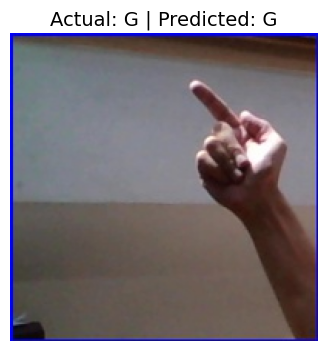

Actual Label:    G
Predicted Label: G


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def predict_and_show_with_truth(img_path):
    # Extract actual label from folder name 
    actual_label = img_path.split("/")[-2]

    # Load and preprocess image
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Image not found at {img_path}")

    # Convert color and resize for model input
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_input = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_input = np.expand_dims(img_input, axis=0).astype('float32') / 255.0

    # Predict with trained model
    pred = model.predict(img_input)
    predicted_label = label_list[np.argmax(pred)]

    # Show image with labels
    plt.figure(figsize=(4,4))
    plt.imshow(img_rgb)
    plt.title(f"Actual: {actual_label} | Predicted: {predicted_label}", fontsize=14)
    plt.axis('off')
    plt.show()

    # Print in console too
    print(f"Actual Label:    {actual_label}")
    print(f"Predicted Label: {predicted_label}")

predict_and_show_with_truth("/kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train/G/G387.jpg")


In [67]:
# Save the model in HDF5 format
model.save("asl_cnn_model.h5")


In [68]:
from google.colab import files
files.download("asl_cnn_model.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>